# Concept Evoluition Tree Example

Before running this program, please make sure to run Topic_Modeling.ipynb to generate the necessary intermediate files.

You can achieve batch data export by modifying the loop range in the last cell of the code and setting the SAVE_NAME variable.

In [251]:
import json
import os
import pandas as pd
import numpy as np
import networkx as nx
from collections import defaultdict, Counter
from typing import List, Dict
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rcParams["font.size"] = 24

## K-shell algorithm

By modifying the size of the sep parameter, you can set the time granularity of the Concept Evolution Tree.

In the output table, the time_window column records the end time of the time window.

top_k means that all such concepts are retained which score in the k-shell algorithm is no lower than top_k among all scores.

In [252]:
def k_shell(
    sep: int, paper_keywords: list, paper_years: np.array, top_k: int = 1
) -> pd.DataFrame:
    # Create year intervals
    start_year = min(paper_years)
    end_year = max(paper_years)
    year_ranges = sorted([(y - sep, y) for y in range(end_year + 1, start_year, -sep)])

    print(f"start_year: {start_year}, end_year: {end_year}")
    print(f"year_ranges: {year_ranges}")

    # Record the number of papers in each time period
    year_paper_count = defaultdict(int)

    # Initialize the data structure used to store the results
    results = []

    # Count the frequency of each keyword in each time period and apply K-shell algorithm
    for year_range in year_ranges:
        # Build a graph and count keyword frequencies
        H = nx.Graph()
        keyword_freq = defaultdict(int)

        for i, keywords in enumerate(paper_keywords):
            if year_range[0] <= paper_years[i] < year_range[1]:
                display_names = [kw["display_name"] for kw in keywords]
                for name in display_names:
                    keyword_freq[name] += 1
                year_paper_count[year_range[1]] += 1

                # Add edges (i.e. two keywords that co-occur in the same paper)
                # Make sure there are at least two keywords to form an edge
                if len(display_names) > 1:
                    H.add_edges_from(
                        [
                            (display_names[j], display_names[k])
                            for j in range(len(display_names))
                            for k in range(j + 1, len(display_names))
                        ]
                    )

        H.remove_edges_from(nx.selfloop_edges(H))

        # Apply K-shell algorithm to find important keywords
        core_numbers = nx.core_number(H)
        important_keywords = {
            k: v
            for k, v in core_numbers.items()
            if v >= max(core_numbers.values(), default=0) - top_k + 1
        }

        # Add important keywords and their frequency to the result list
        for keyword, freq in Counter(
            {k: keyword_freq[k] for k in important_keywords}
        ).items():
            results.append(
                {
                    "time_window": f"{year_range[1]}",
                    "keyword": keyword,
                    "count": freq,
                    "rate": freq / year_paper_count[year_range[1]],
                }
            )

    # Create a DataFrame and sort by time_window
    df = pd.DataFrame(results)
    df.sort_values(by="time_window", inplace=True)
    return df

In [253]:
def calculate_keyword_derivations(
    data: List[Dict], years: List[int], k: int = 5
) -> Dict[str, List[str]]:
    """
    Calculate keyword derivations and return a dictionary where each key is a keyword and the value
    is a list of top-k potential derivation sources sorted by importance.

    Parameters:
    - data: List[Dict] - A list where each entry is a dict containing a "display_name" field with keyword strings.
    - years: List[int] - A list of publication years corresponding to each entry in the data.
    - k: int - Number of top derivation sources to return for each keyword (default: 5).

    Returns:
    - Dict[str, List[str]] - A dictionary where keys are keywords and values are top-k derivation sources.
    """

    # Step 1: Initialize structures
    keyword_data = defaultdict(
        lambda: {"years": [], "co_occurrences": defaultdict(int)}
    )
    derivations = defaultdict(list)

    # Step 2: Populate keyword data with years and co-occurrences
    for i, entry in enumerate(data):
        year = years[i]
        keywords = [kw["display_name"] for kw in entry]  # Extract keyword names

        for k1 in keywords:
            keyword_data[k1]["years"].append(year)
            for k2 in keywords:
                if k1 != k2:
                    keyword_data[k1]["co_occurrences"][k2] += 1

    # Step 3: Compute derivation sources for each keyword
    for k1, k1_data in keyword_data.items():
        k1_first_year = min(k1_data["years"])
        candidate_sources = []

        for k2, co_occurrence in k1_data["co_occurrences"].items():
            k2_first_year = min(keyword_data[k2]["years"])

            # Ensure k2 can be a source for k1
            if k2_first_year < k1_first_year:
                candidate_sources.append((k2, co_occurrence))

        # Sort candidates by co-occurrence importance and keep top-k
        sorted_sources = sorted(candidate_sources, key=lambda x: x[1], reverse=True)
        derivations[k1] = [source[0] for source in sorted_sources[:k]]

    return derivations

In [254]:
def assign_x_positions_with_alternation(intervals):
    """
    Assign x coordinates.
    Arrange nodes alternately to the left and right sides of the trunk.
    This is designed for the version that do not show derivation relationships.
    """
    intervals = sorted(intervals, key=lambda x: x[1])  # Sort by end year
    x_positions = {}  # Record the x coordinate of the keyword
    used_positions = []  # Store the interval assigned to each horizontal axis

    for keyword, start, end in intervals:
        assigned = False
        # Traverse the currently used x coordinates to check whether they can be placed
        for i, pos in enumerate(used_positions):
            if pos[-1] < start:  # No overlap
                used_positions[i].append(end)
                x_positions[keyword] = (
                    (-1 if i % 2 == 0 else 1) * (i // 2 + 1) * 2
                )  # Alternate left and right distribution
                assigned = True
                break
        # If no position is available, assign a new x coordinate
        if not assigned:
            x_positions[keyword] = (
                (-1 if len(used_positions) % 2 == 0 else 1)
                * (len(used_positions) // 2 + 1)
                * 2
            )
            used_positions.append([end])
    return x_positions


def assign_x_positions(keyword_lifetime: dict, derivations: dict) -> dict:
    """
    Assign x coordinates.
    This is a layout function designed for a derivative version.
    """
    # Keyword -> New derived keyword
    keyword_child = {k: [] for k in keyword_lifetime.keys()}
    root_k = []
    for keyword in keyword_lifetime.keys():
        find = False
        for source_keyword in derivations[keyword]:
            if source_keyword not in keyword_lifetime.keys():
                continue
            if keyword_lifetime[source_keyword][0] >= keyword_lifetime[keyword][0]:
                continue
            keyword_child[source_keyword].append(keyword)
            find = True
            break
        if not find:
            root_k.append(keyword)

    # Sort the child array by appearance time from latest to earliest and
    # end time from earliest to latest
    func_life = lambda x: (-int(keyword_lifetime[x][0]), int(keyword_lifetime[x][1]))
    for k, v in keyword_child.items():
        keyword_child[k] = sorted(v, key=func_life)
    root_k = sorted(root_k, key=func_life)

    # First roughly sort to ensure the basic order
    x_rough = {}

    def dfs(fa: str, bias: float) -> None:
        x_fa = x_rough[fa]
        new_bias = bias / (len(keyword_child[fa]) + 3.0)
        for i, c in enumerate(keyword_child[fa]):
            x_rough[c] = (2 if (i % 2) == 0 else -2) * (i // 2 + 0.5) * new_bias + x_fa
            dfs(c, new_bias)

    for i, c in enumerate(root_k):
        x_rough[c] = (1 if (i % 2) == 0 else -1) * (i // 2 + 0.5)
        dfs(c, 0.5)

    # Re-arrange
    sort_keywords = sorted(x_rough.keys(), key=lambda x: x_rough[x])
    left_count = len([v for v in x_rough.values() if v < 0])
    x_positions = {
        k: i - left_count + (1 if i >= left_count else 0)
        for i, k in enumerate(sort_keywords)
    }
    return x_positions


def draw_concept_evolution_tree(
    top_keywords,
    topic_name,
    topic_i,
    topic_id,
    show_derivations=True,
    derivations=None,
    vertical=False,
    save_name=None,
):
    # Data preprocessing
    years = sorted(top_keywords["time_window"].unique())
    keyword_lifetime = {}
    for _, row in top_keywords.iterrows():
        if row["keyword"] not in keyword_lifetime:
            keyword_lifetime[row["keyword"]] = [row["time_window"], row["time_window"]]
        else:
            keyword_lifetime[row["keyword"]][1] = row["time_window"]

    # save keyword_lifetime
    if save_name is not None:
        table = {
            "keyword": [k for k in keyword_lifetime.keys()],
            "start_year": [v[0] for v in keyword_lifetime.values()],
            "end_year": [v[1] for v in keyword_lifetime.values()],
        }
        df = pd.DataFrame.from_dict(table)
        df.to_csv(
            f'./tree_csv_{save_name}/{topic_i}_{topic_name.strip().replace(" ", "_")}.csv'
        )
        with open(
            f'./paper_id_{save_name}/{topic_i}_{topic_name.strip().replace(" ", "_")}.csv',
            mode="w",
            encoding="utf-8",
        ) as f:
            json.dump(topic_id, f)

    if not show_derivations:
        # Assign x coordinates, making sure to alternate left and right
        intervals = [(k, v[0], v[1]) for k, v in keyword_lifetime.items()]
        x_positions = assign_x_positions_with_alternation(intervals)
    else:
        x_positions = assign_x_positions(keyword_lifetime, derivations)

    # Constructing nodes and edges
    keyword_positions = []
    trunk_positions = []  # Store trunk nodes separately
    edges = []
    keyword_last_position = {}
    trunk_x = 0
    for year_idx, year in enumerate(years):
        # Trunk Node
        trunk_positions.append((trunk_x, year_idx))
        current_keywords = top_keywords[top_keywords["time_window"] == year]
        keyword_new_position = {}
        for _, row in current_keywords.iterrows():
            keyword = row["keyword"]
            count = row["count"]
            keyword_x = x_positions[keyword]  # Get the x coordinate of the keyword
            keyword_y = year_idx
            keyword_positions.append((keyword_x, keyword_y, keyword))
            if keyword not in keyword_last_position:
                find_derivations = False
                if show_derivations:  # Derived Relationship Connection
                    for keyword_from in derivations[keyword]:
                        if keyword_from in keyword_last_position:
                            start_x, start_y = keyword_last_position[keyword_from]
                            find_derivations = True
                            break
                if (
                    not find_derivations
                ):  # No derivative relationship, from the main trunk
                    start_x, start_y = trunk_x, year_idx - 1
            else:
                start_x, start_y = keyword_last_position[keyword]
            edges.append((start_x, start_y, keyword_x, keyword_y, count))
            keyword_new_position[keyword] = (keyword_x, keyword_y)
        # Delay the writing of keyword_last_position to avoid interfering with
        # derived relationship connections
        keyword_last_position.update(keyword_new_position)
        
    pic_width = max(len(keyword_last_position) // 4 + 3, 15)

    # Drawing
    if vertical:
        plt.figure(figsize=(pic_width, 25))
        counts = [edge[4] for edge in edges]
        bias = 1
        norm = LogNorm(vmin=1, vmax=max(counts) + bias)
        cmap = plt.cm.Greens

        # Drawing the tree trunk
        height = [-2, len(years) + 2.5]
        for x, y in trunk_positions:
            plt.plot([x, x], height, color="#654321", linewidth=5, zorder=0)

        # Draw the tree trunk labels
        plt.text(
            trunk_x - 1,
            -1,
            topic_name,
            fontsize=24,
            ha="center",
            va="bottom",
            rotation="vertical",
            color="#654321",
            zorder=4,
            fontweight="bold",
        )

        # Draw Edges
        for start_x, start_y, end_x, end_y, count in edges:
            plt.plot(
                [start_x, end_x],
                [start_y, end_y],
                color=cmap(norm(count + bias)),
                linewidth=12 * norm(count + bias),
                alpha=0.9,
                zorder=1,
            )

        # Draw keyword nodes
        for x, y, keyword in keyword_positions:
            plt.scatter(x, y, color="skyblue", s=60, zorder=2)
            if y == keyword_last_position[keyword][1]:
                plt.text(
                    x,
                    y,
                    keyword,
                    fontsize=22,
                    ha="center",
                    va="bottom",
                    rotation=90,
                    zorder=3,
                    # fontweight="bold",
                )

        # Setting the Axis
        plt.title(
            f'Concept Evolution Tree of the Topic "{topic_name.strip()}"', fontsize=24
        )
        plt.xlabel("Concepts Derived", fontsize=24)
        plt.ylabel("Years", fontsize=24)
        plt.xticks([])  # Hide x-axis scale
        plt.yticks(
            range(len(years)),
            [f"[{int(y) - (int(years[1]) - int(years[0]))}, {y})" for y in years],
            fontsize=24,
        )
        plt.ylim(height[0], height[1])
        plt.tight_layout()
    else:
        plt.figure(figsize=(27, pic_width))
        counts = [edge[4] for edge in edges]
        bias = 1
        norm = LogNorm(vmin=1, vmax=max(counts) + bias)
        cmap = plt.cm.Greens

        # Drawing the tree trunk
        height = [-2, len(years) + 2.5]
        for x, y in trunk_positions:
            plt.plot(height, [x, x], color="#654321", linewidth=5, zorder=0)

        # Draw the tree trunk labels
        plt.text(
            -1,
            trunk_x - 1,
            topic_name,
            fontsize=24,
            ha="left",
            va="center",
            color="#654321",
            zorder=4,
            fontweight="bold",
        )

        # Draw Edges
        for start_x, start_y, end_x, end_y, count in edges:
            plt.plot(
                [start_y, end_y],
                [start_x, end_x],
                color=cmap(norm(count + bias)),
                linewidth=12 * norm(count + bias),
                alpha=0.9,
                zorder=1,
            )

        # Draw keyword nodes
        for x, y, keyword in keyword_positions:
            plt.scatter(y, x, color="skyblue", s=60, zorder=2)
            if y == keyword_last_position[keyword][1]:
                plt.text(
                    y + 0.05,
                    x,
                    keyword,
                    fontsize=22,
                    ha="left",
                    va="center",
                    rotation=0,
                    zorder=3,
                )

        # Setting the Axis
        plt.title(
            f'Concept Evolution Tree of the Topic "{topic_name.strip()}"', fontsize=24
        )
        plt.xlabel("Years", fontsize=24)
        plt.ylabel("Concepts Derived", fontsize=24)
        plt.xticks(
            range(len(years)),
            [f"[{int(y) - (int(years[1]) - int(years[0]))}, {y})" for y in years],
            fontsize=24,
            rotation=-15,
            ha="left",
        )
        plt.yticks([])  # Hide y-axis scale
        plt.xlim(height[0], height[1])
        plt.tight_layout()

    if save_name is not None:
        plt.savefig(
            f'./tree_fig_{save_name}/{topic_i}_{topic_name.strip().replace(" ", "_")}.pdf'
        )
    else:
        plt.savefig(f'./pic_for_paper/2.2 - Tree of the Topic {topic_name.strip()}.pdf')
        # plt.savefig(f'./pic_for_paper/4.1 - Tree of the Topic {topic_name.strip()}.pdf')

In [255]:
def get_subtree(
    top_keywords,
    derivations,
    paper_id: list,
    paper_keyword: list,
    paper_year: list,
):
    # Create the result list structure
    result = []

    # Only consider keywords that appear in top_keywords
    keyword_lifetime = {}
    for _, row in top_keywords.iterrows():
        if row["keyword"] not in keyword_lifetime:
            keyword_lifetime[row["keyword"]] = [row["time_window"], row["time_window"]]
        else:
            keyword_lifetime[row["keyword"]][1] = row["time_window"]

    # Construct the inverse map: a map from a parent node to all direct child nodes
    reverse_derivations = {}
    for child, parents in derivations.items():
        if child not in keyword_lifetime.keys():
            continue
        parent = None
        for p in parents:
            if p not in keyword_lifetime.keys():
                continue
            if keyword_lifetime[p][0] >= keyword_lifetime[child][0]:
                continue
            parent = p
            break
        if parent == None:
            continue  # Skip keywords that are not in top_keywords
        if parent not in reverse_derivations:
            reverse_derivations[parent] = []
        reverse_derivations[parent].append(child)

    # Calculate the subtree information of a given keyword
    def get_subtree_info(keyword):
        unique_keywords = set([keyword])
        span = keyword_lifetime[keyword]

        def dfs(node):
            if node in reverse_derivations:
                for child in reverse_derivations[node]:
                    unique_keywords.add(child)
                    dfs(child)

        dfs(keyword)

        # Get the time window of the keyword and all keywords in its subtree
        for k in unique_keywords:
            span[1] = max(span[1], keyword_lifetime[k][1])

        return len(unique_keywords), int(span[1]) - int(span[0]) + 5

    # Get the ID and keywords of the article that appears first at the root of the subtree
    def get_origin_paper(
        target_keyword: str,
        target_year: int,
        paper_id: list,
        paper_keyword: list,
        paper_year: list,
    ):
        origin_id = None
        origin_year = 2025
        origin_keyword = []
        for id, keywords, year in zip(paper_id, paper_keyword, paper_year):
            if target_keyword not in (k["display_name"] for k in keywords):
                continue
            # start from root of subtree
            if target_year > year:
                continue
            if year > origin_year:
                continue
            origin_id = id
            origin_year = year
            origin_keyword = [k["display_name"] for k in keywords]
        return origin_id, origin_keyword

    # Traverse each keyword that exists in top_keywords
    for keyword, span in keyword_lifetime.items():
        unique_keywords_count, span_length = get_subtree_info(keyword)
        origin_id, origin_keyword = get_origin_paper(
            keyword, int(span[0]) - 5, paper_id, paper_keyword, paper_year
        )
        result.append(
            {
                "keyword": keyword,
                "width": unique_keywords_count,
                "height": span_length,
                "area": unique_keywords_count * span_length,
                "fork": (
                    0
                    if keyword not in reverse_derivations.keys()
                    else len(reverse_derivations[keyword])
                ),
                "thick": top_keywords.loc[
                    top_keywords[["keyword"]].eq(keyword).any(axis=1), "count"
                ].mean(),
                "rate": top_keywords.loc[
                    top_keywords[["keyword"]].eq(keyword).any(axis=1), "rate"
                ].mean(),
                "start_year": span[0],
                "origin_id": origin_id,
                "origin_keyword": json.dumps(origin_keyword),
            }
        )

    result = sorted(result, key=lambda x: x["area"], reverse=True)

    return pd.DataFrame(result)

[72] Music Information Retrieval Systems
Number of papers in this topic: 158
start_year: 1979, end_year: 2024
year_ranges: [(1975, 1980), (1980, 1985), (1985, 1990), (1990, 1995), (1995, 2000), (2000, 2005), (2005, 2010), (2010, 2015), (2015, 2020), (2020, 2025)]


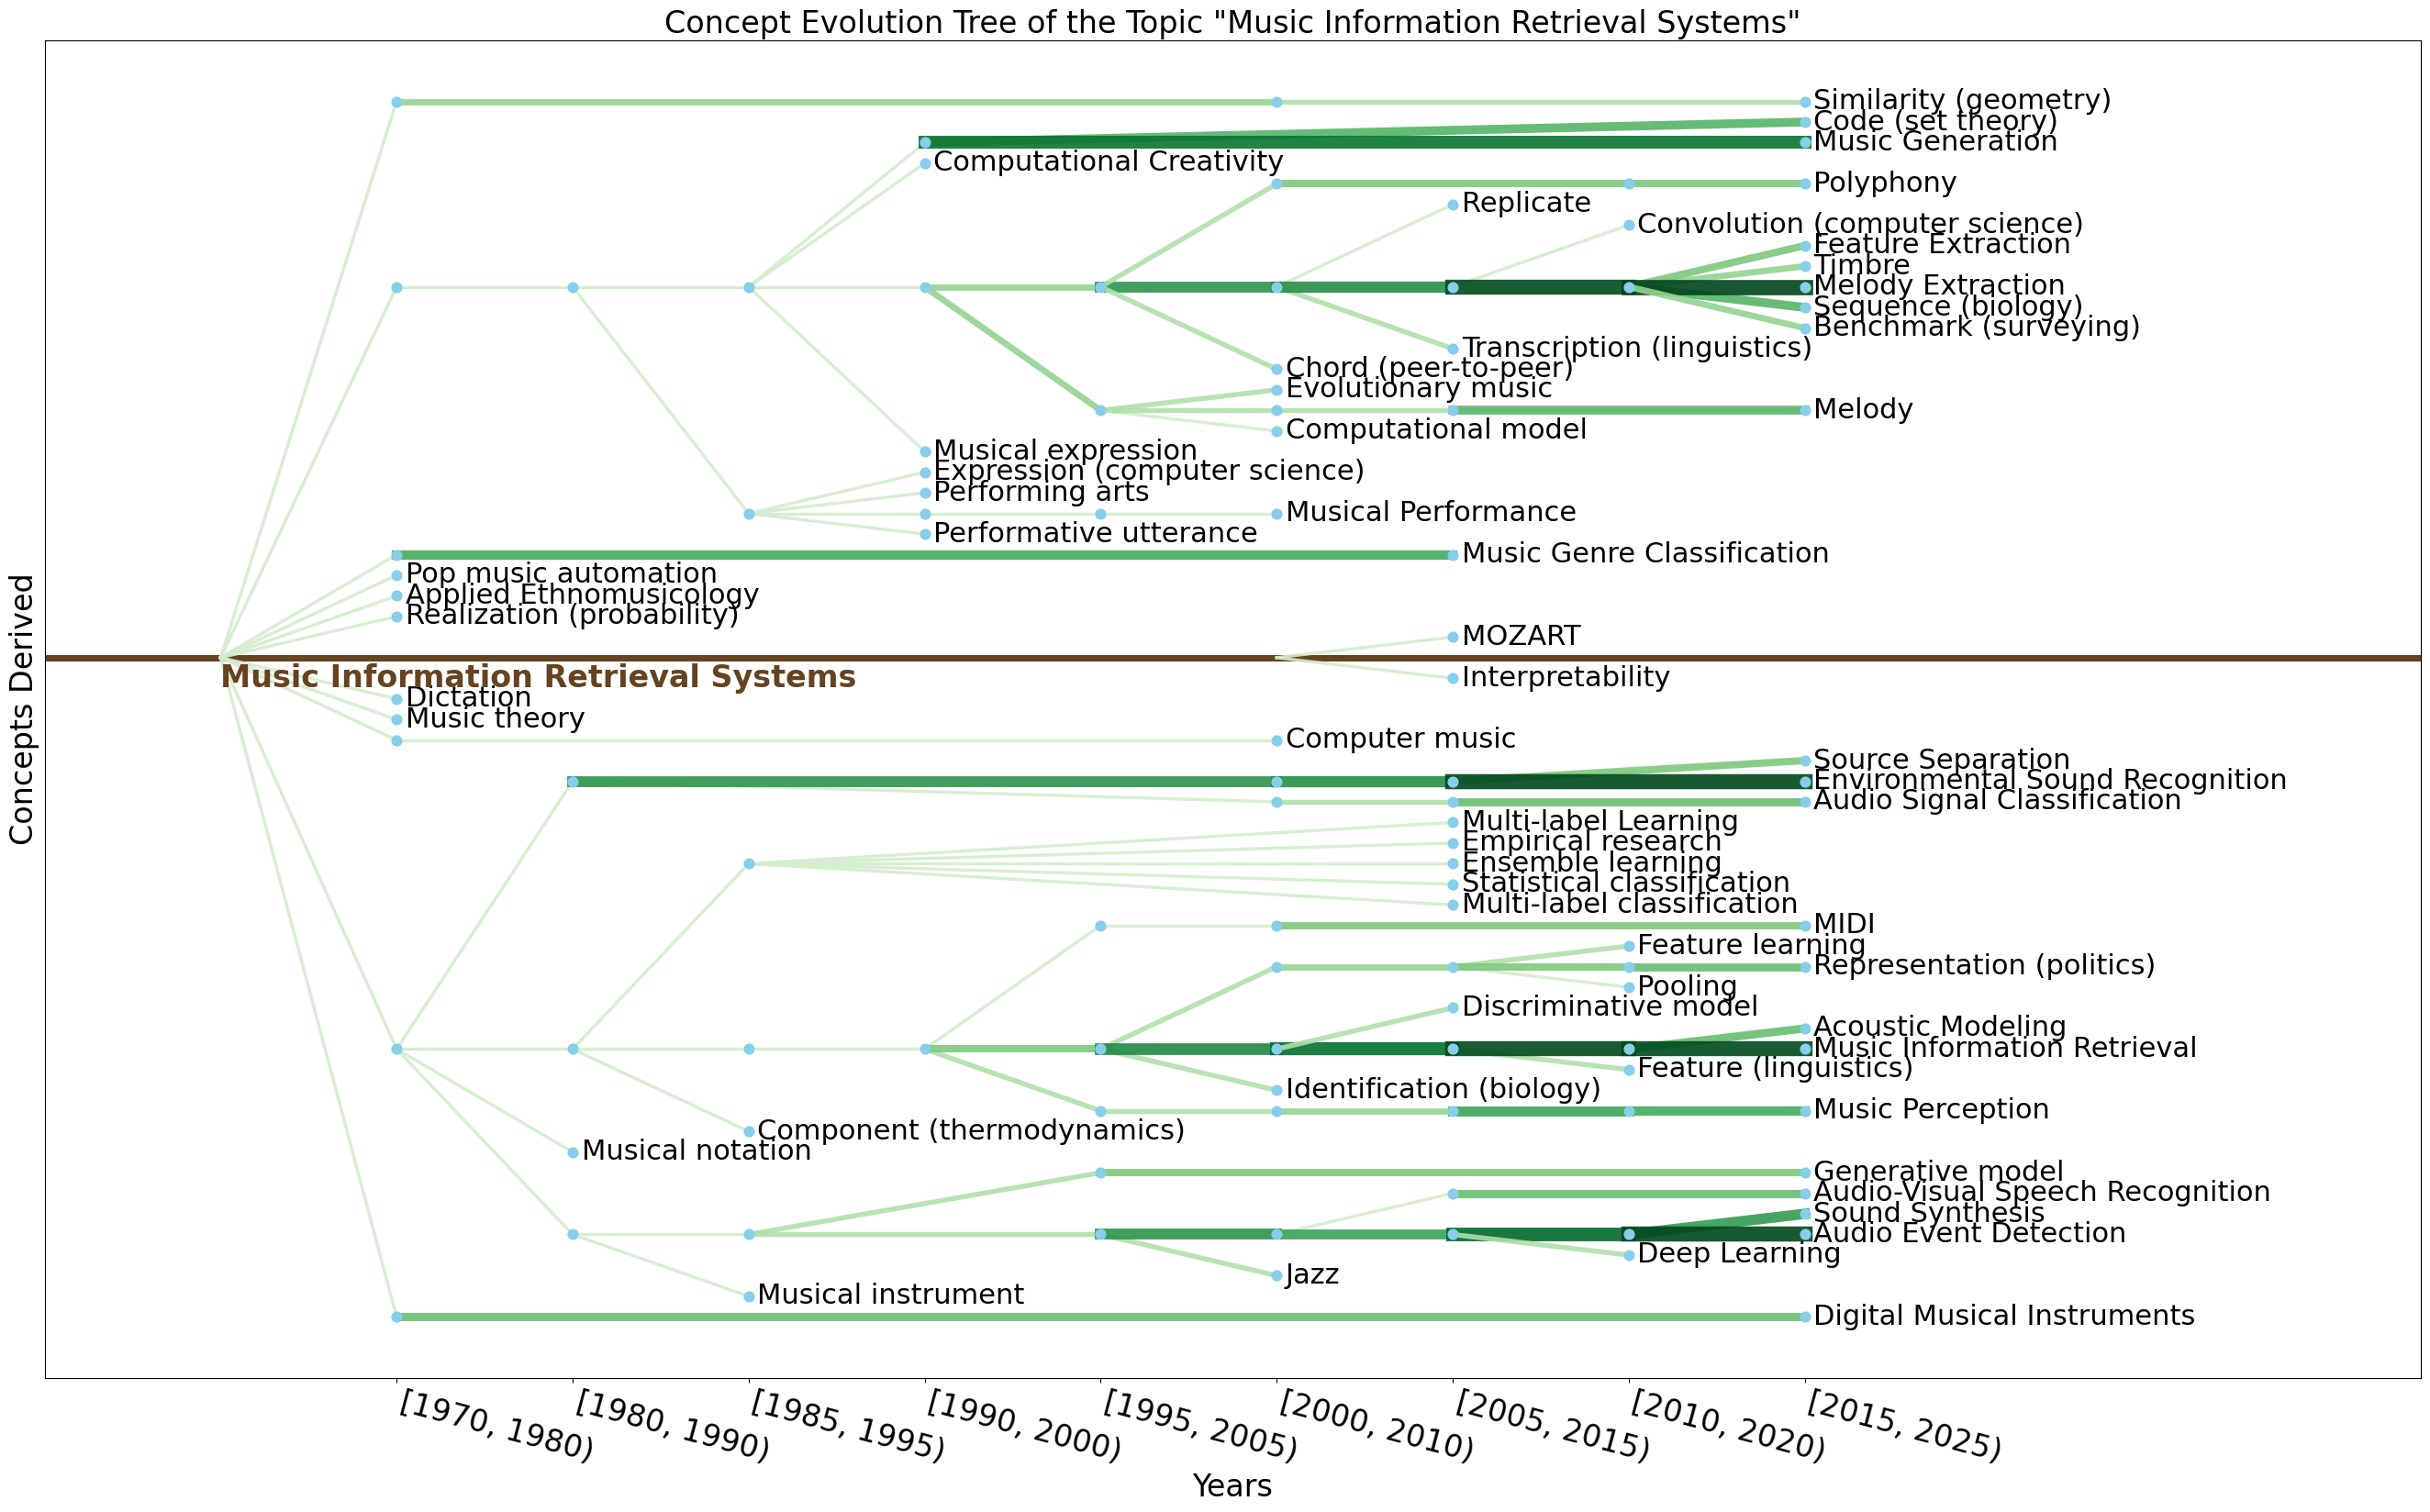

In [256]:
# Topic select: keep the for loop open to export tree in batches.
# Default displays topic #72, "Music Information Retrieval Systems".
for i in range(72, 73):
    TOPIC_I = i
    TOPIC_DIR = "./topics_csr_ai"  # Modify here to switch topics
    STEP = 5  # Adjust the analysis time granularity.
    SAVE_NAME = None  # When SAVE_NAME is not None, more data will be saved.
    # SAVE_NAME = "csr_ai"

    with open(os.path.join(TOPIC_DIR, f"{TOPIC_I}.txt"), "r", encoding="utf-8") as f:
        data = json.load(f)
        TOPIC_NAME = data["topic_name"]
        TOPIC_ID = data["topic_id"]
        TOPIC_YEAR = data["topic_year"]
        TOPIC_KEYWORD = data["topic_keyword"]

    print(f"[{TOPIC_I}] {TOPIC_NAME}")
    print(f"Number of papers in this topic: {len(TOPIC_ID)}")

    TOPIC_TOP_KEYWORD = k_shell(STEP, TOPIC_KEYWORD, TOPIC_YEAR, top_k=1)

    TOPIC_DERIVATION = calculate_keyword_derivations(TOPIC_KEYWORD, TOPIC_YEAR, 1)

    # Drawing a graph
    draw_concept_evolution_tree(
        TOPIC_TOP_KEYWORD,
        TOPIC_NAME,
        TOPIC_I,
        TOPIC_ID,
        show_derivations=True,
        derivations=TOPIC_DERIVATION,
        vertical=False,
        save_name=SAVE_NAME,
    )

    # The `get_subtree` function is the specific implementation for retrieving subtree information on our website.
    # Uncommenting the code below will save the subtree information in CSV format.
    # subtree = get_subtree(
    #     TOPIC_TOP_KEYWORD, TOPIC_DERIVATION, TOPIC_ID, TOPIC_KEYWORD, TOPIC_YEAR
    # )
    # subtree.to_csv(f'./subtree_csv/{TOPIC_I}_{TOPIC_NAME.strip().replace(" ", "_")}.csv')